In [32]:
!pip install wandb -q
import wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [33]:
import os
import pathlib, json, glob, shutil, zipfile
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import Input, Model, layers
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

In [34]:
data_path = pathlib.Path("data")
colab_path = pathlib.Path("/content/data")

if not data_path.exists() and not colab_path.exists():
    print("Data not found. Extracting from Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    
    zip_src = pathlib.Path('/content/drive/MyDrive/data.zip')
    shutil.unpack_archive(zip_src, '/content') # Automatically handles unzipping
    data_path = colab_path
else:
    data_path = data_path if data_path.exists() else colab_path

df = pd.read_csv(data_path / 'train.csv')
image_dir = data_path / 'train_images' / 'train_images'

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [35]:
le = LabelEncoder()
train_labels = le.fit_transform(train_df['TARGET'])
val_labels = le.transform(val_df['TARGET'])

train_paths = train_df['file_name'].map(lambda name: str(image_dir / str(name))).to_numpy()
val_paths = val_df['file_name'].map(lambda name: str(image_dir / str(name))).to_numpy()

def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    label = tf.one_hot(label, depth=100)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
    .shuffle(buffer_size=len(train_paths))
    .map(process_path, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
    .map(process_path, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [36]:
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.11),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
], name="data_augmentation")

def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

def build_resnet18(input_shape=(224, 224, 3), num_classes=100):
    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    for filters, blocks, stride in [(64, 2, 1), (128, 2, 2), (256, 2, 2), (512, 2, 2)]:
        x = residual_block(x, filters, stride=stride)
        for _ in range(1, blocks):
            x = residual_block(x, filters)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return Model(inputs, outputs, name="resnet18")

model_CNN = build_resnet18()

model_CNN.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_CNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_9[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 112, 112,  │      9,408 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_80[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_68 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ re_lu_68[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 56, 56,    │     36,864 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_81[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_69 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 56, 56,    │     36,864 │ re_lu_69[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_82[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_70 (ReLU)     │ (None, 56, 56,    │          0 │ add_32[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 56, 56,    │     36,864 │ re_lu_70[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_83[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_71 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 56, 56,    │     36,864 │ re_lu_71[0][0]  

 Total params: 11,237,412 (42.87 MB)

 Trainable params: 11,227,812 (42.83 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
wandb.init(
    project="ELEC378FinalProject",
    config={
        "learning_rate": 1e-3,
        "architecture": "ResNet18",
        "dataset": "train_images",
        "epochs": 30,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "loss_function": "categorical_crossentropy"
    }
)

In [38]:
wandb_callbacks = [
    WandbMetricsLogger(),
    WandbModelCheckpoint(
        filepath="best_resnet18_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model_CNN.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=wandb_callbacks
)

wandb.finish()

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 69s 678ms/step - accuracy: 0.1376 - loss: 3.7239 - val_accuracy: 0.0103 - val_loss: 90.6712
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 637ms/step - accuracy: 0.2975 - loss: 2.7325 - val_accuracy: 0.0187 - val_loss: 6.8065
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 675ms/step - accuracy: 0.4046 - loss: 2.2722 - val_accuracy: 0.0441 - val_loss: 6.3195
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 641ms/step - accuracy: 0.4879 - loss: 1.8653 - val_accuracy: 0.1056 - val_loss: 4.6547
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 639ms/step - accuracy: 0.5735 - loss: 1.5560 - val_accuracy: 0.2568 - val_loss: 3.6320
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 638ms/step - accuracy: 0.6062 - loss: 1.3858 - val_accuracy: 0.4780 - val_loss: 2.1806
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 626ms/step - accuracy: 0.6546 - loss: 1.2234 - val_accuracy: 0.3624 - val_loss: 3.0900
Epoch 8/30
 8/79 ━━━━━━━━━━━━━━━━━━━━ 42s 597ms/step - accuracy: 0.6681 - loss: 1.1492

wandb: WARNING Artifact "run_qat9nsck_model" already exists with the same content. No new version will be created.


79/79 ━━━━━━━━━━━━━━━━━━━━ 55s 700ms/step - accuracy: 0.6965 - loss: 1.0735 - val_accuracy: 0.5343 - val_loss: 1.9485
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 648ms/step - accuracy: 0.7169 - loss: 0.9976 - val_accuracy: 0.3640 - val_loss: 2.9913
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 641ms/step - accuracy: 0.7378 - loss: 0.9190 - val_accuracy: 0.6002 - val_loss: 1.6311
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 82s 639ms/step - accuracy: 0.7625 - loss: 0.8251 - val_accuracy: 0.5760 - val_loss: 1.7068
Epoch 12/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 651ms/step - accuracy: 0.7648 - loss: 0.8032 - val_accuracy: 0.6356 - val_loss: 1.5243
Epoch 13/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 634ms/step - accuracy: 0.7901 - loss: 0.7179 - val_accuracy: 0.4716 - val_loss: 2.3558
Epoch 14/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 49s 625ms/step - accuracy: 0.8069 - loss: 0.6702 - val_accuracy: 0.3081 - val_loss: 5.7633
Epoch 15/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 645ms/step - accuracy: 0.8114 - loss: 0.6303 - val_accuracy:

epoch/accuracy,▁▂▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇████████████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▁▂▃▅▄▆▄▆▆▇▅▄▇▇▆▇▇█▆▆▇▇██▇▇▇█
epoch/val_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.91454
epoch/epoch,29
epoch/learning_rate,0.001
epoch/loss,0.27946
epoch/val_accuracy,0.78682


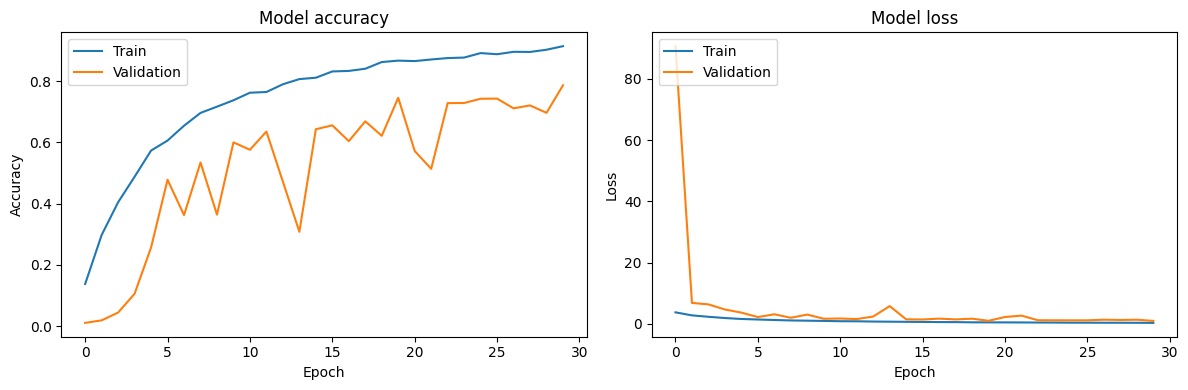

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()